# Spark: pierwszy kontakt


In [ ]:
# !apt-get install openjdk-8-jdk-headless -qq > /dev/null
# !wget -q http://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

In [ ]:
# !tar xf spark-3.5.1-bin-hadoop3.tgz
# !pip install -q findspark

In [ ]:
# !ls

sample_data  spark-3.5.1-bin-hadoop3  spark-3.5.1-bin-hadoop3.tgz


In [ ]:
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

In [ ]:
# import findspark
# findspark.init()

In [1]:
from pyspark.sql import SparkSession
import random
import numpy as np

# Przykład

In [2]:
# spark = SparkSession.builder.master("local[*]").getOrCreate()
# spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

def inside(p):
    x, y = random.random(), random.random()
    return x*x + y*y < 1

NUM_SAMPLES = 10000000

count = sc.parallelize(range(0, NUM_SAMPLES)).filter(inside).count()
print("Pi is roughly %f" % (4.0 * count / NUM_SAMPLES))

spark.stop()


Pi is roughly 3.142355


# Zadanie 1 – całkowanie Monte Carlo
Korzystając z API RDD napisz krótki skrypt, który policzy całkę oznaczoną z $x^2 +1$ w zakresie od 0 do 2
korzystając z metody Monte Carlo (czyli w praktyce wylosuje dużo punktów w pewnym prostokącie,
sprawdzi ile z nich znalazło się pod wykresem funkcji, oraz przemnoży ten ułamek przez pole
prostokąta). Porównaj uzyskany wynik z rozwiązaniem analitycznym (jeżeli nie pamiętamy jak się
całkowało – to można je dostać np. na WolframAlpha…). Można inspirować się podobnym
przykładem dla obliczania liczby pi (https://spark.apache.org/examples.html ).

In [3]:
spark.stop()

spark = SparkSession.builder.master("local[*]").appName("MonteCarloIntegral").getOrCreate()
sc = spark.sparkContext
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

In [4]:
def f(x):
    return x**2 + 1

# Integration range [a, b]
a = 0
b = 2

# Determine the maximum value of the function in the range [0, 2]
# f(0) = 1, f(2) = 5. So, max_y = 5
max_y = f(b) # Since f(x) is monotonically increasing in [0, 2]

# Area of the bounding rectangle
rectangle_area = (b - a) * max_y

NUM_SAMPLES_INTEGRAL = 10000000

def is_under_curve(p):
    x_rand, y_rand = random.uniform(a, b), random.uniform(0, max_y)
    return y_rand < f(x_rand)

# Generate random points and count how many fall under the curve
count_under_curve = sc.parallelize(range(0, NUM_SAMPLES_INTEGRAL)).filter(is_under_curve).count()

# Calculate the Monte Carlo integral approximation
monte_carlo_integral = (count_under_curve / NUM_SAMPLES_INTEGRAL) * rectangle_area

# Analytical solution for integral of x^2 + 1 from 0 to 2
# Integral of x^2 + 1 is (x^3 / 3) + x
analytical_integral = (2**3 / 3 + 2) - (0**3 / 3 + 0)

print(f"Monte Carlo Integral: {monte_carlo_integral}")
print(f"Analytical Integral: {analytical_integral}")
print(f"Difference: {abs(monte_carlo_integral - analytical_integral)}")

Monte Carlo Integral: 4.668586
Analytical Integral: 4.666666666666666
Difference: 0.0019193333333342721


In [5]:
spark.stop()

# Zadanie 2 – statystyka porównawcza tekstów
Wraz z instrukcją dostarczono również spore pliki tekstowe, zawierające dwa dzieła literackie które
na zawsze zmieniły oblicze Europy. Porównaj statystykę występujących w nich charakterystycznych
słów. Dla każdej z ksiąg wypisz 20 najczęściej występujących w niej słów, spośród tych, których
częstotliwość występowania w danym dziele jest przynajmniej 5 razy większa niż w drugim z nich
(bierzemy pod uwagę tylko słowa występujące w obu księgach).
Konieczne będzie wczytanie tekstów z plików, ich podział na słowa, sprowadzenie wszystkich do
lowercase, wyczyszczenie (usunięcie cyfr czy znaków przestankowych), policzenie częstotliwości
wystąpień, odfiltrowanie tych spełniających zadany warunek, a na koniec wypisanie wyniku.
Korzystamy z API RDD.


In [6]:
spark.stop()

spark = SparkSession.builder.appName("TextComparison").getOrCreate()
sc = spark.sparkContext

# Load the text files
manifesto_rdd = sc.textFile("the_communist_manifesto.txt")
bible_rdd = sc.textFile("the_king_james_bible.txt")

print("Loaded the_communist_manifesto.txt. First line:")
print(manifesto_rdd.first())
print("\nLoaded the_king_james_bible.txt. First line:")
print(bible_rdd.first())

Loaded the_communist_manifesto.txt. First line:
MANIFESTO OF THE COMMUNIST PARTY

Loaded the_king_james_bible.txt. First line:
The Old Testament of the King James Version of the Bible


In [7]:
import re

def preprocess_text(line):
    # Convert to lowercase
    line = line.lower()
    # Remove numbers and punctuation, keep only letters and spaces
    line = re.sub(r'[^a-z\s]', '', line)
    # Split into words and filter out empty strings
    words = [word for word in line.split() if word]
    return words

# Process the RDDs to get words and their counts
manifesto_word_counts = manifesto_rdd.flatMap(preprocess_text).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)
bible_word_counts = bible_rdd.flatMap(preprocess_text).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

print("Sample word counts from Manifesto:")
print(manifesto_word_counts.take(5))
print("\nSample word counts from Bible:")
print(bible_word_counts.take(5))

Sample word counts from Manifesto:
[('of', 779), ('party', 8), ('from', 40), ('edition', 1), ('by', 112)]

Sample word counts from Bible:
[('old', 381), ('of', 34670), ('king', 2258), ('james', 45), ('version', 1)]


In [8]:
# Join the two RDDs to compare word frequencies for common words
# We use a full outer join to keep all words, then filter later for common ones
# For words present in both, we'll get (word, (count_manifesto, count_bible))
# For words only in one, the other count will be None

# First, convert RDDs to (word, (source, count)) for easier joining and tracking
manifesto_with_source = manifesto_word_counts.map(lambda x: (x[0], ('manifesto', x[1])))
bible_with_source = bible_word_counts.map(lambda x: (x[0], ('bible', x[1])))

# Perform a full outer join
joined_counts = manifesto_word_counts.fullOuterJoin(bible_word_counts)

# Filter for words that appear in both texts and apply the 5x frequency condition
def filter_and_compare(word_tuple):
    word, counts = word_tuple
    manifesto_count = counts[0] if counts[0] is not None else 0
    bible_count = counts[1] if counts[1] is not None else 0

    # Only consider words present in both texts (count > 0 in both)
    if manifesto_count > 0 and bible_count > 0:
        if manifesto_count >= 5 * bible_count:
            return True
        elif bible_count >= 5 * manifesto_count:
            return True
    return False

filtered_common_words = joined_counts.filter(filter_and_compare)

# Separate words based on which text they are more dominant in
manifesto_dominant_words = filtered_common_words.filter(lambda x: x[1][0] is not None and (x[1][0] >= 5 * (x[1][1] if x[1][1] is not None else 0)))
bible_dominant_words = filtered_common_words.filter(lambda x: x[1][1] is not None and (x[1][1] >= 5 * (x[1][0] if x[1][0] is not None else 0)))

# Sort and take the top 20 for each
top_20_manifesto = manifesto_dominant_words.sortBy(lambda x: x[1][0], ascending=False).take(20)
top_20_bible = bible_dominant_words.sortBy(lambda x: x[1][1], ascending=False).take(20)

print("\nTop 20 words significantly more frequent in The Communist Manifesto:")
for word, counts in top_20_manifesto:
    print(f"  Word: {word}, Manifesto Count: {counts[0]}, Bible Count: {counts[1]}")

print("\nTop 20 words significantly more frequent in The King James Bible:")
for word, counts in top_20_bible:
    print(f"  Word: {word}, Manifesto Count: {counts[0]}, Bible Count: {counts[1]}")


Top 20 words significantly more frequent in The Communist Manifesto:
  Word: its, Manifesto Count: 78, Bible Count: 1
  Word: has, Manifesto Count: 68, Bible Count: 1
  Word: conditions, Manifesto Count: 50, Bible Count: 1
  Word: freedom, Manifesto Count: 10, Bible Count: 2
  Word: private, Manifesto Count: 10, Bible Count: 1
  Word: condition, Manifesto Count: 9, Bible Count: 1
  Word: parties, Manifesto Count: 8, Bible Count: 1

Top 20 words significantly more frequent in The King James Bible:
  Word: the, Manifesto Count: 1137, Bible Count: 64023
  Word: and, Manifesto Count: 344, Bible Count: 51696
  Word: of, Manifesto Count: 779, Bible Count: 34670
  Word: to, Manifesto Count: 262, Bible Count: 13580
  Word: that, Manifesto Count: 125, Bible Count: 12912
  Word: in, Manifesto Count: 287, Bible Count: 12667
  Word: he, Manifesto Count: 10, Bible Count: 10419
  Word: shall, Manifesto Count: 1, Bible Count: 9838
  Word: for, Manifesto Count: 79, Bible Count: 8970
  Word: i, Manife

In [9]:
spark.stop()

# Zadanie 3 – wizualizacja rozkładu słów w tekstach
Na koniec prześledzimy rozkład chmury słów w obu dokumentach, korzystając z API DataFrame i
gotowych rozwiązań z MLlib. Zrobimy to w następujący sposób:
* wczytamy oba teksty dzieląc je po kropkach na zdania
* scalimy je następnie do jednego DF
* użyjemy RegexTokenizera by podzielić zdania na słowa
* użyjemy StopWordsRemovera by usunąć słowa nieistotne semantycznie
* użyjemy algorytmu Word2Vec by każdemu ze słów przypisać (na podstawie kontekstu w
którym występowało) dwuwymiarowy wektor je reprezentujący
* wyniki zapiszemy do pliku w postaci trzech kolumn (z której książki pochodziło słowo –
wartość pierwszej współrzędnej wektora – wartość drugiej współrzędnej wektora)
* zwizualizujemy dowolnym narzędziem pozwalającym na rysowanie scatter plots
* efekt powinien być podobny jak poniżej




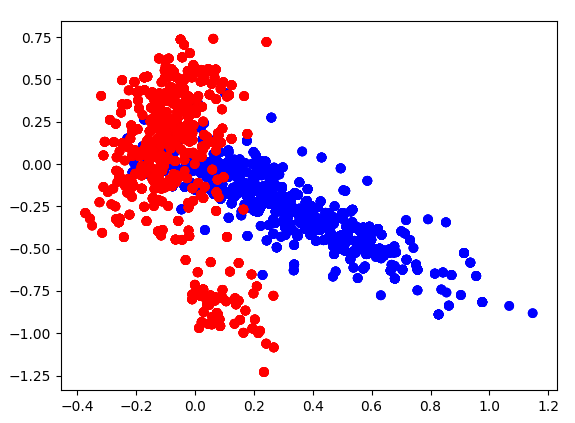

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import split, explode, lower, regexp_replace, array_contains, udf
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, Word2Vec
from pyspark.sql.types import StringType, ArrayType, FloatType
import matplotlib.pyplot as plt
import pandas as pd
import re

# Stop any existing SparkSession
spark.stop()

# Initialize a new SparkSession for DataFrame operations
spark = SparkSession.builder.appName("WordCloudVisualization").getOrCreate()
sc = spark.sparkContext

# Load the text files
manifesto_rdd = sc.textFile("the_communist_manifesto.txt")
bible_rdd = sc.textFile("the_king_james_bible.txt")

# Function to split text into sentences and assign source
def process_text_to_sentences(rdd, source_name):
    # Split by period and filter out empty strings
    sentences_rdd = rdd.flatMap(lambda line: re.split(r'\.', line))
    sentences_rdd = sentences_rdd.filter(lambda sentence: sentence.strip() != '')
    # Create a DataFrame with sentence and source
    return spark.createDataFrame(sentences_rdd.map(lambda s: (s.strip(), source_name)), ['sentence', 'source'])

# Process both texts
manifesto_df = process_text_to_sentences(manifesto_rdd, 'manifesto')
bible_df = process_text_to_sentences(bible_rdd, 'bible')

# Union the two DataFrames
combined_df = manifesto_df.unionAll(bible_df)

print("Combined DataFrame schema:")
combined_df.printSchema()
print("\nSample sentences from combined DataFrame:")
combined_df.show(5, truncate=False)

Combined DataFrame schema:
root
 |-- sentence: string (nullable = true)
 |-- source: string (nullable = true)


Sample sentences from combined DataFrame:
+-----------------------------------------------------------------+---------+
|sentence                                                         |source   |
+-----------------------------------------------------------------+---------+
|MANIFESTO OF THE COMMUNIST PARTY                                 |manifesto|
|[From the English edition of 1888, edited by Friedrich Engels]   |manifesto|
|A spectre is haunting Europe--the spectre of Communism           |manifesto|
|All the Powers of old Europe have entered into a holy alliance to|manifesto|
|exorcise this spectre: Pope and Czar, Metternich and Guizot,     |manifesto|
+-----------------------------------------------------------------+---------+
only showing top 5 rows


In [35]:
# Apply RegexTokenizer to split sentences into words
tokenizer = RegexTokenizer(inputCol="sentence", outputCol="words", pattern="[^a-zA-z]+")
tokenized_df = tokenizer.transform(combined_df)

print("Tokenized DataFrame schema:")
tokenized_df.printSchema()
print("\nSample tokenized sentences:")
tokenized_df.show(5, truncate=False)

Tokenized DataFrame schema:
root
 |-- sentence: string (nullable = true)
 |-- source: string (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)


Sample tokenized sentences:
+-----------------------------------------------------------------+---------+-------------------------------------------------------------------------------+
|sentence                                                         |source   |words                                                                          |
+-----------------------------------------------------------------+---------+-------------------------------------------------------------------------------+
|MANIFESTO OF THE COMMUNIST PARTY                                 |manifesto|[manifesto, of, the, communist, party]                                         |
|[From the English edition of 1888, edited by Friedrich Engels]   |manifesto|[[from, the, english, edition, of, edited, by, friedrich, engels]]

In [36]:
# Remove stop words
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
filtered_df = stopwords_remover.transform(tokenized_df)

print("Filtered DataFrame schema:")
filtered_df.printSchema()
print("\nSample filtered sentences:")
filtered_df.show(5, truncate=False)

Filtered DataFrame schema:
root
 |-- sentence: string (nullable = true)
 |-- source: string (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)


Sample filtered sentences:
+-----------------------------------------------------------------+---------+-------------------------------------------------------------------------------+-----------------------------------------------------+
|sentence                                                         |source   |words                                                                          |filtered_words                                       |
+-----------------------------------------------------------------+---------+-------------------------------------------------------------------------------+-----------------------------------------------------+
|MANIFESTO OF THE COMMUNIST PARTY               

In [37]:
# Train a Word2Vec model
# The outputCol will store the word embeddings (vectors)
word2Vec = Word2Vec(vectorSize=2, minCount=20, inputCol="filtered_words", outputCol="word_vectors")
model = word2Vec.fit(filtered_df)

# Transform the DataFrame to get word vectors
word_vectors_df = model.transform(filtered_df)

print("Word Vectors DataFrame schema:")
word_vectors_df.printSchema()
print("\nSample word vectors:")
word_vectors_df.show(5, truncate=False)

Word Vectors DataFrame schema:
root
 |-- sentence: string (nullable = true)
 |-- source: string (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- word_vectors: vector (nullable = true)


Sample word vectors:
+-----------------------------------------------------------------+---------+-------------------------------------------------------------------------------+-----------------------------------------------------+--------------------------------------------+
|sentence                                                         |source   |words                                                                          |filtered_words                                       |word_vectors                                |
+-----------------------------------------------------------------+---------+---------------------------------------------------

In [38]:
# Get the word vectors from the trained model
word_embeddings_df = model.getVectors()

# Prepare a DataFrame with individual words and their source
words_with_source_df = filtered_df.select("source", explode("filtered_words").alias("word"))

# Join the word embeddings with the source information
# We will use an inner join to only keep words that have an embedding (i.e., minCount condition was met)
final_word_vectors_df = words_with_source_df.join(word_embeddings_df, on="word", how="inner").distinct()

# Extract x and y components from the vector
get_vector_x = udf(lambda vector: float(vector[0]), FloatType())
get_vector_y = udf(lambda vector: float(vector[1]), FloatType())

final_word_vectors_df = final_word_vectors_df.withColumn("vector_x", get_vector_x(final_word_vectors_df["vector"])) \
                                           .withColumn("vector_y", get_vector_y(final_word_vectors_df["vector"]))

# Select the required columns: source, word, vector_x, vector_y
plot_df = final_word_vectors_df.select("source", "word", "vector_x", "vector_y")

print("Final DataFrame for plotting schema:")
plot_df.printSchema()
print("\nSample of final word vectors for plotting:")
plot_df.show(5, truncate=False)

Final DataFrame for plotting schema:
root
 |-- source: string (nullable = true)
 |-- word: string (nullable = true)
 |-- vector_x: float (nullable = true)
 |-- vector_y: float (nullable = true)


Sample of final word vectors for plotting:
+---------+-----------+-------------+-----------+
|source   |word       |vector_x     |vector_y   |
+---------+-----------+-------------+-----------+
|manifesto|bourgeoisie|-1.6782805E-4|0.058314033|
|manifesto|oppress    |-0.054952834 |-0.3320147 |
|manifesto|confess    |-0.20134546  |-0.15242925|
|manifesto|stand      |-0.5764294   |-0.22523728|
|manifesto|instruments|0.385969     |-0.5212543 |
+---------+-----------+-------------+-----------+
only showing top 5 rows


In [39]:
# Save the results to a CSV file
# Using coalesce(1) to write to a single file, though not recommended for large datasets
output_path = "word_vectors_for_plotting.csv"
plot_df.coalesce(1).write.mode("overwrite").option("header", "true").csv(output_path)

print(f"Word vectors saved to {output_path}/")

Word vectors saved to word_vectors_for_plotting.csv/


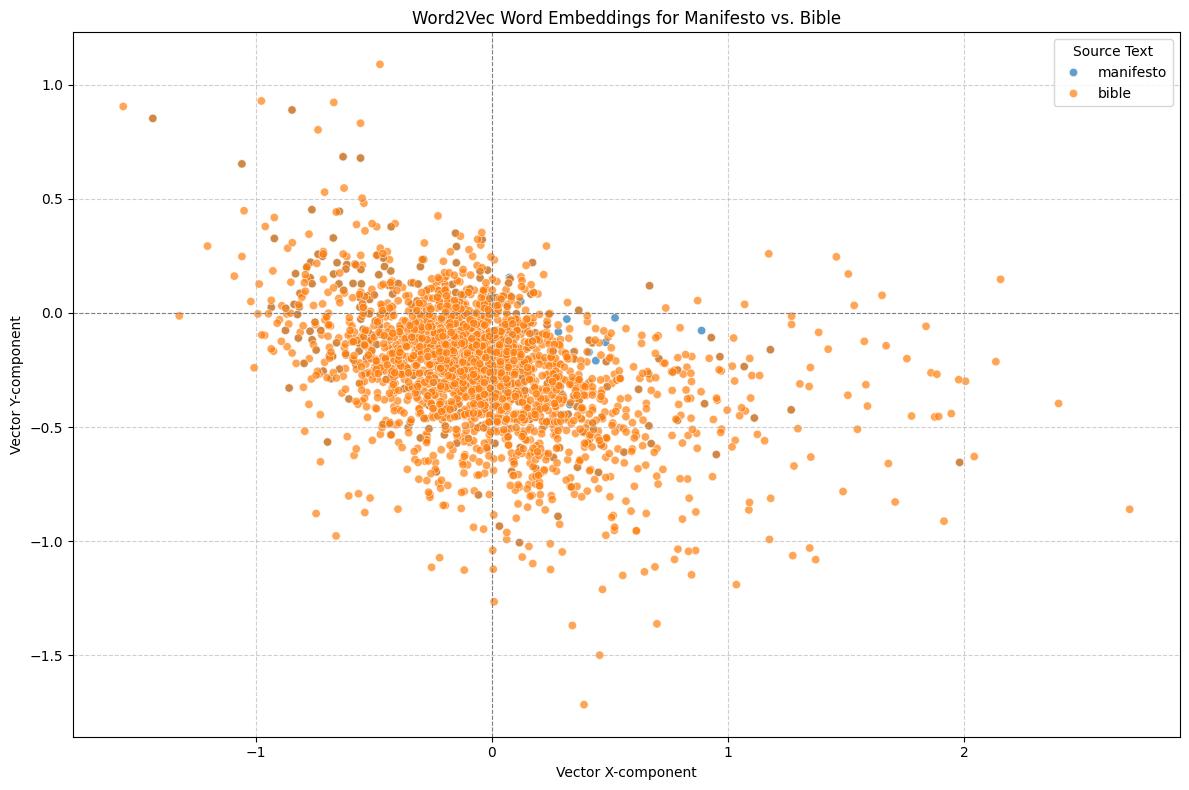

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the saved CSV file into a pandas DataFrame for plotting
# Spark saves CSVs into a directory, so we need to find the actual file
csv_files = [f for f in os.listdir(output_path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(output_path, csv_files[0])
    plot_df_pd = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("No CSV file found in the output directory.")

# Create the scatter plot
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(x='vector_x', y='vector_y', hue='source', data=plot_df_pd, alpha=0.7)
plt.title('Word2Vec Word Embeddings for Manifesto vs. Bible')
plt.xlabel('Vector X-component')
plt.ylabel('Vector Y-component')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Source Text')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add x-axis line at 0
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add y-axis line at 0
plt.tight_layout()
plt.show()

# Nie wiem jak mam coś zrobić – jak żyć?
Prowadzący powinien rozpocząć zajęcia od krótkiego wstępu. Będzie on pobieżnym streszczenie oficjalnych materiałów szkoleniowych od Apache. W szczególności zaś:
* https://spark.apache.org/docs/latest/quick-start.html (szybki start ze Sparkiem)
* https://spark.apache.org/docs/latest/rdd-programming-guide.html (wprowadzenie do RDD)
* https://spark.apache.org/docs/latest/sql-programming-guide.html (wprowadzenie do DataFrames)
* https://spark.apache.org/docs/latest/ml-guide.html (wprowadzenie do MLliba)
* oraz najważniejszego, czyli dokumentacji samego API - https://spark.apache.org/docs/latest/api/python/pyspark.html

P.S. Nie martw się, jeżeli nie zdążysz zrobić wszystkich zadań – zostały przygotowane „na zapas”, na wypadek gdyby ich rozwiązywanie szło bardzo szybko.